# TESS Exoplanet Pipeline: Project Architecture & Step-by-Step Walkthrough

Welcome to the comprehensive guide and walkthrough for the **TESS Exoplanet Pipeline**. This notebook explains the system's architecture, its design, and provides a step-by-step walkthrough of each pipeline stage.

## 1. Project Overview & Objectives

The TESS Exoplanet Pipeline is a modular, high-performance Python package designed for automated exoplanet detection, stellar characterization, and Bayesian transit modeling. It handles:
1. **Target Resolution**: Resolving target coordinates and identifiers using MAST, local archives, and FITS files.
2. **Data Acquisition & Preprocessing**: Querying and downloading TESS light curves from MAST or reading local FITS files, followed by stitching, sigma-clipping, and flattening.
3. **Transit Detection**: Executing Transit Least Squares (TLS) or Box Least Squares (BLS) to detect periodic transits.
4. **Stellar Characterization**: Querying Gaia DR3 to derive stellar radius, mass, temperature, and density, with fallback options.
5. **Bayesian Transit Modeling**: Performing Markov Chain Monte Carlo (MCMC) sampling with PyMC and the `exoplanet` library to fit transit models and GP noise.
6. **Reporting**: Creating high-fidelity diagnostic figures and generating an interactive HTML report of the analysis.

## 2. Core Architecture & Modules

The codebase is structured under `src/tess_pipeline/` as follows:

- **`config.py`**: Controls pipeline execution settings via `PipelineConfig`. Supports custom settings for MCMC (chains, draws, tune), GP kernels, and data query cadence.
- **`results.py`**: Serves as the central repository (`PipelineResults`) for storing data, catalog tables, posterior samples, and generated figures.
- **`analysis/session.py`**: Exposes the high-level `TESSAnalysis` orchestrator class which executes the pipeline stages sequentially.
- **`analysis/stages/`**: Contains the modular class implementations for each step:
  - `TargetStage`: Target resolution.
  - `LightCurveStage`: Downloading, parsing, and preprocessing (clipping/flattening).
  - `PeriodStage`: Local catalog queries and TLS/BLS search.
  - `StellarStage`: Gaia DR3 TAP query and stellar parameter estimation.
  - `InferenceStage`: Bayesian PyMC MCMC transit fit and parameter derivation.
  - `VisualizationStage`: Building the final diagnostic figures.
- **`transit/`**: Implementations of TLS and BLS search routines.
- **`inference/`**: Exoplanet PyMC model definition, Sho GP noise kernel, and parameter derivation logic.
- **`visualization/`**: Submodule for generating high-quality scientific figures (phase curves, corner plots, residuals, etc.).
- **`io/`**: Handles file exporting (JSON, CSV) and compilation of the interactive HTML report.

--- 

## Step-by-Step Walkthrough

Below is the sequential walkthrough of the pipeline using the high-level interactive interface `TESSAnalysis`.

### Step 0: Imports & Configuration

To start, import the orchestrator class `TESSAnalysis`. Configure a session either by passing a TIC ID for remote MAST download or pointing to local FITS files.

In [1]:
%matplotlib inline
from tess_pipeline import TESSAnalysis

In [7]:
# # Local FITS mode initialization (runs on TOI-1)
# FITS_PATH = "../data/fits/tess2018206045859-s0001-0000000261136679-0120-s_lc.fits"

# analysis = TESSAnalysis(
#     lightcurve_source="fits",
#     lightcurve_fits=[FITS_PATH],
#     inference=True,
#     search_method="tls",
#     plots=True,
#     verbose=True,
#     chains=1,
#     draws=100,
#     tune=100
# )


# run the analsis on a given TIC id
from tess_pipeline import TESSAnalysis

# Configure the pipeline session for the target TIC ID
analysis = TESSAnalysis(
    target="TIC 158297421",    # <-- Replace with your TIC ID (string or integer)
    lightcurve_source="download",  # remote download mode
    inference=True,            # run Bayesian MCMC transit fit
    search_method="tls",       # run Transit Least Squares search
    sectors=3,                 # number of TESS sectors to fetch
    cadence=120,               # target cadence in seconds (120 or 1800)
    chains=2,                  # MCMC chains (increase for science runs)
    draws=2,                 # MCMC draws per chain
    tune=2,                  # MCMC tuning steps per chain
    plots=True,                # generate diagnostic figures
    verbose=True               # print detailed log output
)



### Step 1: Resolve Target

This step calls the `TargetStage`. For FITS inputs, it inspects FITS headers to resolve target metadata (TIC ID, RA, Dec). For MAST downloads, it queries MAST naming services.

In [8]:
analysis.resolve_target()
analysis.results.target

18:45:40  INFO      tess_pipeline.analysis.stages.target  Resolving target: TIC 158297421
18:45:40  DEBUG     tess_pipeline.data.metadata  Resolved 'TIC 158297421' to TIC 158297421
18:45:40  INFO      tess_pipeline.catalogs.nasa_archive  Using local NASA archive CSV /home/astro-nitesh/Desktop/Siya/exoplanet_modelling/tess_exoplanet_pipeline/data/TOI_2026.06.28_09.42.00.csv for TIC 158297421 (matched 1 row(s))
18:45:40  INFO      tess_pipeline.data.metadata  Loaded coordinates for TIC 158297421 from local archive
18:45:40  INFO      tess_pipeline.analysis.stages.target  Resolved to TIC 158297421


{'tic_id': 158297421,
 'name': 'TIC 158297421',
 'ra': 287.484402,
 'dec': -49.664942}

### Step 2: Query Published Catalog Period

This queries the local NASA Exoplanet Archive TOI catalog to check if the target has a published period. If found, it establishes a reference period and epoch for the upcoming stages.

In [9]:
analysis.lookup_archive_period()
analysis.results.period

18:45:41  INFO      tess_pipeline.analysis.stages.period  Querying NASA Exoplanet Archive for TIC 158297421
18:45:41  INFO      tess_pipeline.catalogs.nasa_archive  Using local NASA archive CSV /home/astro-nitesh/Desktop/Siya/exoplanet_modelling/tess_exoplanet_pipeline/data/TOI_2026.06.28_09.42.00.csv for TIC 158297421 (matched 1 row(s))
18:45:41  INFO      tess_pipeline.analysis.stages.period  Archive period: 3.922802 d (ref: Local NASA Exoplanet Archive TOI export: /home/astro-nitesh/Desktop/Siya/exoplanet_modelling/tess_exoplanet_pipeline/data/TOI_2026.06.28_09.42.00.csv)


{'value': 3.9228016,
 'source': 'archive',
 'reference': 'Local NASA Exoplanet Archive TOI export: /home/astro-nitesh/Desktop/Siya/exoplanet_modelling/tess_exoplanet_pipeline/data/TOI_2026.06.28_09.42.00.csv'}

### Step 3: Load Light Curves

This step calls the `LightCurveStage` to load the FITS file(s) into memory (or download them from MAST in download mode).

In [10]:
raw_lcs = analysis.load_lightcurves()
raw_lcs

18:45:42  INFO      tess_pipeline.analysis.stages.lightcurve  Downloading TESS data for TIC 158297421
18:45:42  INFO      tess_pipeline.data.download  [download] Starting download for TIC 158297421 (author=SPOC, cadence=120, sectors=3, force_download=False)
18:45:42  INFO      tess_pipeline.data.download  [download] Step 1/5: validated input arguments
18:45:42  INFO      tess_pipeline.data.download  [download] Local FITS files not found (or force_download=True), querying MAST
18:45:42  INFO      tess_pipeline.data.download  [download] Step 3/5: searching MAST for TIC 158297421 with timeout=120s
18:45:44  INFO      tess_pipeline.data.download  [download] Found 4 available sector(s) for TIC 158297421
18:45:44  INFO      tess_pipeline.data.download  [download] Step 4/5: selected 3 sector(s) for analysis
18:45:44  INFO      tess_pipeline.data.download  [download] Step 5/5: downloading selected light curve products


18:46:08  INFO      tess_pipeline.data.download  [fits] Step 1/4: normalizing FITS paths
18:46:08  INFO      tess_pipeline.data.download  [fits] Step 2/4: 3 FITS file(s) queued
18:46:08  INFO      tess_pipeline.data.download  [fits] Step 3/4: reading file 1/3: data/fits/tess2020186164531-s0027-0000000158297421-0189-s_lc.fits


18:46:08  INFO      tess_pipeline.data.download  [fits] Step 3/4: reading file 2/3: data/fits/tess2023181235917-s0067-0000000158297421-0261-s_lc.fits


18:46:09  INFO      tess_pipeline.data.download  [fits] Step 3/4: reading file 3/3: data/fits/tess2019169103026-s0013-0000000158297421-0146-s_lc.fits
18:46:09  INFO      tess_pipeline.data.download  [fits] Step 4/4: loaded 3 light curve(s) from local FITS in 1.3s
18:46:09  INFO      tess_pipeline.data.download  [download] Completed TIC 158297421 download in 26.6s (3 sector file(s))


### Step 4: Preprocess Light Curves

Stitches light curves together, applies sigma-clipping, and flattens out low-frequency stellar variability (e.g. using a GP or spline filter). 

If `plots=True`, this automatically saves intermediate raw and flattened diagnostic plots to the target's output directory.

18:46:21  INFO      tess_pipeline.analysis.stages.lightcurve  Preprocessing light curves
18:46:21  DEBUG     tess_pipeline.data.preprocess  Stitched 3 sectors → 43329 cadences
18:46:23  INFO      tess_pipeline.data.preprocess  Preprocessing complete: 43327 cadences remain
18:46:24  INFO      tess_pipeline.analysis.session  Saved step plot: output/TIC 158297421/plots/raw.png
18:46:25  INFO      tess_pipeline.analysis.session  Saved step plot: output/TIC 158297421/plots/flat.png


time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float64,float64,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
2036.2839373715556,9.8351003e-01,1.2064791e-02,5.1894672e-03,582353,120.52695,430.45560,5.9512354e+02,4.3141556e+00,6.1215137e+02,1.5947316e+00,5.6221002e+02,6.8966722e+00,0,———,———,———,———,120.52695,3.4353505e-03,430.45560,3.4375440e-03,3.5622094e-02,-2.5677022e-02
2036.2867151322273,9.9356397e-01,1.2111937e-02,5.1894514e-03,582355,120.52669,430.45959,5.9977655e+02,4.3300285e+00,6.1524854e+02,1.5969278e+00,5.6782788e+02,6.9220462e+00,0,———,———,———,———,120.52669,3.4213623e-03,430.45959,3.4237227e-03,3.3778466e-02,-1.6868295e-02
2036.288104012564,9.9417508e-01,1.2097192e-02,5.1894435e-03,582356,120.52793,430.44943,5.9909998e+02,4.3237829e+00,6.1330713e+02,1.5967675e+00,5.6804913e+02,6.9120617e+00,0,———,———,———,———,120.52793,3.4201532e-03,430.44943,3.4233024e-03,3.4249317e-02,-2.3378741e-02
2036.2894928933654,1.0012561e+00,1.2114153e-02,5.1894360e-03,582357,120.52305,430.45358,6.0232013e+02,4.3288789e+00,6.1436169e+02,1.5957749e+00,5.7196747e+02,6.9202089e+00,0,———,———,———,———,120.52305,3.4063002e-03,430.45358,3.4090120e-03,3.4978826e-02,-1.5875092e-02
2036.2908817737014,1.0027142e+00,1.2098257e-02,5.1894281e-03,582358,120.52810,430.46092,6.0189734e+02,4.3222432e+00,6.1149170e+02,1.5923218e+00,5.7267383e+02,6.9096012e+00,0,———,———,———,———,120.52810,3.4040215e-03,430.46092,3.4056981e-03,3.5462998e-02,-2.2673411e-02
2036.292270654038,9.9722455e-01,1.2096570e-02,5.1894202e-03,582359,120.52992,430.45695,6.0007495e+02,4.3206968e+00,6.1137665e+02,1.5941598e+00,5.6941412e+02,6.9071283e+00,0,———,———,———,———,120.52992,3.4128670e-03,430.45695,3.4146914e-03,3.5921011e-02,-1.8144710e-02
2036.2936595348394,9.8041945e-01,1.2081164e-02,5.1894127e-03,582360,120.52857,430.45796,5.9439325e+02,4.3142610e+00,6.1211951e+02,1.5956014e+00,5.5969739e+02,6.8968396e+00,0,———,———,———,———,120.52857,3.4390914e-03,430.45796,3.4412977e-03,3.4195390e-02,-1.6938472e-02
2036.2950484151754,9.9292360e-01,1.2095200e-02,5.1894048e-03,582361,120.52555,430.46081,5.9825861e+02,4.3183489e+00,6.1380182e+02,1.5961429e+00,5.6671442e+02,6.9033747e+00,0,———,———,———,———,120.52555,3.4202612e-03,430.46081,3.4221977e-03,3.9317727e-02,-2.3086634e-02


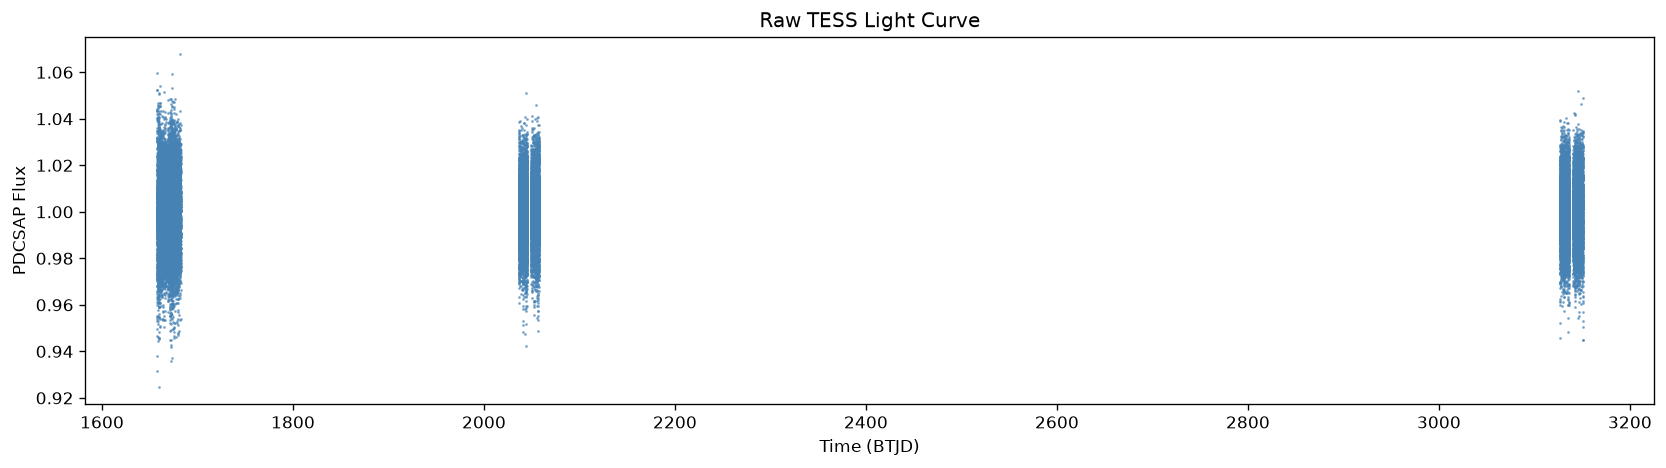

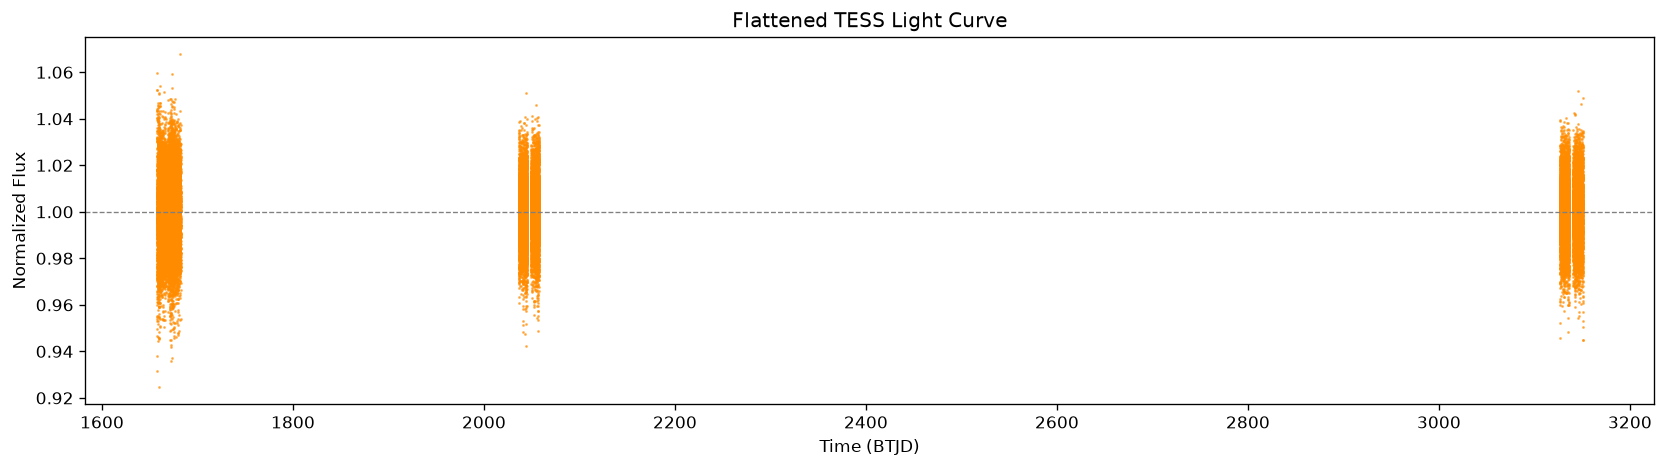

In [11]:
analysis.preprocess()
analysis.results.lightcurve

### Step 5: Transit Search (TLS / BLS)

Runs the Transit Least Squares (TLS) search (or BLS if configured) on the flattened light curve to find planetary transits. It creates periodogram plots and phase-folded curves.

In [15]:
# analysis.search_period()
# analysis.results.detection


# assign the period 
analysis._period.archive_period


3.9228016

### Step 6: Stellar Characterization

Queries Gaia DR3 coordinates via TAP query to resolve stellar parameters (temperature, gravity, parallax). If possible, runs isoclassify models to estimate R★ and M★. If SDSS spectroscopic catalogs have matching matches, resolves radial velocity information.

In [16]:
analysis.query_gaia()
analysis.characterize_star()
analysis.query_sdss()
analysis.results.stellar

18:50:18  INFO      tess_pipeline.analysis.stages.stellar  Querying Gaia DR3
Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST
INFO: Query finished. [astroquery.utils.tap.core]
18:50:37  WARNING   tess_pipeline.catalogs.gaia  Gaia DR3: r_star not available for this source
18:50:37  INFO      tess_pipeline.analysis.stages.stellar  Running stellar characterization (isoclassify)
18:50:37  WARNING   tess_pipeline.catalogs.stellar  Insufficient Gaia parameters for isoclassify (need r_star, teff, parallax)
18:50:37  WARNING   tess_pipeline.catalogs.stellar  isoclassify failed; falling back to Gaia-only parameters
18:50:37  WARNING   tess_pipeline.catalogs.stellar  Gaia R★ unavailable; stellar characterization incomplete
18:50:37  INFO      tess_pipeline.analysis.stages.stellar  Querying SDSS for radial velocity
18:50:39  INFO      tess_pipeline.catalogs.sdss  No SDSS spectroscopic match within 3 arcsec
18:50:39  INFO      tess_pipeline.analysis.stages.stellar

{'r_star': None,
 'r_star_err': None,
 'm_star': None,
 'm_star_err': None,
 'teff': 4550.634765625,
 'teff_err': 4554.958984375,
 'logg': 4.64109992980957,
 'logg_err': None,
 'feh': 0.4681999981403351,
 'feh_err': None,
 'lum': None,
 'lum_err': None,
 'age': None,
 'age_err': None,
 'method': 'gaia_only',
 'rho_star': None,
 'rho_star_err': None}

### Step 7: Bayesian Transit Fit & MCMC Sampling

Runs the `InferenceStage` to perform MCMC sampling using `exoplanet` + PyMC:
- Builds a light curve model incorporating limb-darkened transits and a stellar variability Gaussian Process (using the Celerite2 SHO GP kernel).
- Samples posterior parameters (period, transit epoch, impact parameter, planet-to-star radius ratio, limb-darkening coefficients, stellar density, GP parameters).
- Computes derived physical parameters (e.g. semimajor axis, stellar/planetary radii, densities).
- Runs convergence diagnostics (R-hat, Effective Sample Size, divergence checks).

In [17]:
analysis.fit_transit()


18:51:10  INFO      tess_pipeline.analysis.stages.inference  Running Bayesian transit fit (exoplanet + PyMC)
18:51:10  INFO      tess_pipeline.inference.bayesian  Building PyMC model (N=43327 points, period=3.922802 d)


/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/celerite2/pymc/ops.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


18:51:11  DEBUG     tess_pipeline.inference.gp  Using SHO GP kernel


/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/pytensor/tensor/random/op.py:97: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/pytensor/tensor/random/op.py:107: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(


18:51:11  INFO      tess_pipeline.inference.bayesian  Finding MAP solution
18:51:11  WARNING   tess_pipeline.inference.bayesian  MAP optimization failed (module 'exoplanet' has no attribute 'optimize'); using default initvals
18:51:11  INFO      tess_pipeline.inference.bayesian  Sampling: 2 chains × 2 draws (tune=2, target_accept=0.90)


Only 2 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: _CeleriteOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: QuadSolutionVector should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
Initializing NUTS using jitter+adapt_diag...
<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(float64, shape=(1, 1))) must be 

AssertionError: PyTensor Assert failed!

In [18]:
analysis.derive_planet_parameters()


RuntimeError: Call fit_transit() before derive_planet_parameters()

In [ ]:
analysis.check_convergence()
analysis.results.planet

### Step 8: Diagnostic Figures, Data Export, and Report Compile

Generates publication-quality diagnostic plots (posterior corner plot, sampling traces, phase curves, residuals, and GP fits) and writes output tables to disk. Finally, it compiles an interactive HTML report containing tables and embedded plots.

In [ ]:
analysis.generate_figures()
analysis.save()
analysis.results.summary()

## 3. Project Output Files Structure

After calling `analysis.save()`, you will find the following structure in the configured `output/` directory:

```
output/
└── TIC <TIC_ID>/
    ├── results.json          # Complete JSON summary of metadata, stellar/planet parameters
    ├── planet_parameters.csv  # CSV table of derived physical parameters with uncertainties
    ├── report.html           # Interactive HTML summary report
    └── plots/
        ├── raw.png                   # Raw light curve stitched
        ├── flat.png                  # Flattened light curve
        ├── tls_periodogram.png       # TLS power spectrum
        ├── phase.png                 # Phase-folded light curve
        ├── bayesian_fit.png          # PyMC model transit fit overlay
        ├── corner.png                # MCMC posterior corner correlation plot
        ├── trace.png                 # MCMC trace diagnostics
        ├── posterior_predictive.png  # Posterior predictive model samples
        └── residuals.png             # Fit residuals
```